# 04 — T2 Tuning: Optuna cho M2a XGBoost + M2b LightGBM

exp_003 — [RESULTS chi tiết](../experiments/exp_003_tuning_m2/). Tune CẢ HAI model (không chỉ 1, xem docstring `run.py` — ở exp_002 hai model gần như hoà nhau).

**Cập nhật 2026-09-23:** lần chạy 100-trial đầu tiên (inner=5 origin) cho kết quả T2 TỆ HƠN T1 cho XGBoost (-4.9%) — chẩn đoán là do cửa sổ inner quá nhỏ. Đã tăng `INNER_N_ORIGINS` từ 5 lên **15** để kiểm tra lại giả thuyết đó.

**⚠️ 2 lần chạy trước đều hỏng, đã sửa cả 2 nguyên nhân:**
1. Lần 1: kernel cũ còn cache `run` module trước khi sửa `INNER_N_ORIGINS` → chạy nhầm lại y hệt bản inner=5 (số liệu trùng khớp tuyệt đối, không phải bug tuning). **Sửa:** nhớ Restart Kernel (không chỉ Run All) mỗi khi `run.py` bị sửa.
2. Lần 2: kernel restart đúng (cell "Chuẩn bị dữ liệu" xác nhận `Inner: 15 origin`), XGBoost tune xong thật sau **4116s (~69 phút)** với kết quả MỚI (best inner MASE 0.550, khác hẳn bản inner=5) — nhưng máy tự sleep/tắt trước khi chạy tới LightGBM, mất hết 69 phút đó vì kernel chết không cách nào lấy lại `study_xgb`. **Đã sửa 2 việc:**
   - Thêm `SetThreadExecutionState` (cell đầu) — chủ động báo Windows không sleep trong lúc notebook chạy, không phụ thuộc bạn nhớ chỉnh Settings.
   - Thêm 2 cell **checkpoint** ngay sau mỗi lần tune xong (`checkpoint_xgboost.json`/`checkpoint_lightgbm.json`) — nếu có sự cố khác xảy ra ở LightGBM, ít nhất XGBoost không mất trắng nữa.

**Thời gian đo THẬT (không còn là ngoại suy):** XGBoost 100 trial @ 15 origin = **4116s (~69 phút)**. LightGBM thường nhanh hơn XGBoost ~2.7x (tỷ lệ quan sát được ở bản inner=5 cũ) → ước tính **~25 phút**. **Tổng ước tính lần này: ~95 phút**, không phải "vài giờ" như ghi trước đó — máy có GPU không cần dùng ở đây (CPU-bound), cứ để chạy, giờ đã an toàn khỏi sleep.

Đổi `N_TRIALS` xuống thấp (vd 10) để chạy thử nhanh trước nếu muốn chắc chắn hơn.

In [1]:
import ctypes
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "app").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("project root:", _root)

# Lan chay truoc bi ngat giua chung vi may tu sleep/tat sau ~69 phut, mat het
# tien do XGBoost (khong luu duoc vi kernel chet). Chu dong bao Windows "dung
# ngu" trong luc process nay con song, khong phu thuoc user nho tat sleep
# trong Settings - tu dong het hieu luc khi kernel bi kill/dong.
if sys.platform == "win32":
    ES_CONTINUOUS = 0x80000000
    ES_SYSTEM_REQUIRED = 0x00000001
    ctypes.windll.kernel32.SetThreadExecutionState(ES_CONTINUOUS | ES_SYSTEM_REQUIRED)
    print("Da bao Windows khong sleep trong luc notebook nay chay.")

project root: d:\Cuộc thi\DengueSense\ai-service
Da bao Windows khong sleep trong luc notebook nay chay.


In [2]:
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(_root / 'experiments' / 'exp_003_tuning_m2'))
from run import (
    HORIZONS,
    INNER_CUTOFF,
    INNER_EMBARGO_MONTHS,
    INNER_N_ORIGINS,
    OUTER_EMBARGO_MONTHS,
    OUTER_N_ORIGINS,
    REPORTING_DELAY_MONTHS,
    build_horizon_pairs,
    evaluate_params,
    load_real_panel_with_features,
    tune,
)

from app.forecast.models import fit_predict_m2_lightgbm, fit_predict_m2_xgboost
from app.forecast.splits import make_splits

N_TRIALS = 100

## Chuẩn bị dữ liệu (inner tuning + outer đánh giá, tách biệt hoàn toàn)

In [3]:
feat_panel = load_real_panel_with_features()

inner_panel = feat_panel[feat_panel['month'] <= INNER_CUTOFF]
inner_splits = make_splits(inner_panel, n_origins=INNER_N_ORIGINS, horizons=HORIZONS,
                            embargo_months=INNER_EMBARGO_MONTHS, reporting_delay_months=REPORTING_DELAY_MONTHS)
inner_cache = {h: build_horizon_pairs(inner_panel, h) for h in HORIZONS}

outer_splits = make_splits(feat_panel, n_origins=OUTER_N_ORIGINS, horizons=HORIZONS,
                            embargo_months=OUTER_EMBARGO_MONTHS, reporting_delay_months=REPORTING_DELAY_MONTHS)
outer_cache = {h: build_horizon_pairs(feat_panel, h) for h in HORIZONS}

print(f'Inner: {len(inner_splits)} origin (tune). Outer: {len(outer_splits)} origin (danh gia cuoi).')

Inner: 15 origin (tune). Outer: 8 origin (danh gia cuoi).


## Tune M2a XGBoost

Cell này chạy lâu nhất — xem ước tính thời gian ở đầu notebook (chưa đo thật ở 15 origin, có thể lâu hơn ước tính) — cứ để chạy, không cần theo dõi liên tục.

In [4]:
t0 = time.time()
study_xgb = tune(fit_predict_m2_xgboost, inner_panel, inner_splits, inner_cache, N_TRIALS)
print(f'Xong sau {time.time()-t0:.0f}s')
print('Best inner MASE:', study_xgb.best_value)
print('Best params:', study_xgb.best_params)

Xong sau 29250s
Best inner MASE: 0.5499994074731723
Best params: {'n_estimators': 730, 'learning_rate': 0.047701840975142816, 'max_depth': 4, 'subsample': 0.8427988063619768, 'colsample_bytree': 0.7274552515495886, 'reg_alpha': 0.10598944240972412, 'reg_lambda': 0.005268659354964616}


In [5]:
import json as _json

# Checkpoint NGAY sau khi xong - lan truoc mat het 69 phut cong suc vi may
# tat truoc khi chay den cell luu cuoi cung. Luu rieng ra file dem, doc lai
# duoc ngay ca khi cell LightGBM ben duoi bi ngat giua chung.
_ckpt_xgb = {
    "n_trials": N_TRIALS,
    "best_inner_mase": study_xgb.best_value,
    "best_params": study_xgb.best_params,
    "convergence": [t.value for t in study_xgb.trials],
}
_ckpt_path = _root / "experiments" / "exp_003_tuning_m2" / "checkpoint_xgboost.json"
_ckpt_path.write_text(_json.dumps(_ckpt_xgb, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Checkpoint XGBoost da luu: {_ckpt_path}")

Checkpoint XGBoost da luu: d:\Cuộc thi\DengueSense\ai-service\experiments\exp_003_tuning_m2\checkpoint_xgboost.json


## Tune M2b LightGBM

In [6]:
t0 = time.time()
study_lgb = tune(fit_predict_m2_lightgbm, inner_panel, inner_splits, inner_cache, N_TRIALS)
print(f'Xong sau {time.time()-t0:.0f}s')
print('Best inner MASE:', study_lgb.best_value)
print('Best params:', study_lgb.best_params)

Xong sau 3085s
Best inner MASE: 0.5638671660954855
Best params: {'n_estimators': 640, 'learning_rate': 0.031841510121235, 'max_depth': 5, 'subsample': 0.9180635626534275, 'colsample_bytree': 0.7107698811673616, 'reg_alpha': 1.2605517262775456, 'reg_lambda': 0.0006423068640005983}


In [7]:
import json as _json

_ckpt_lgb = {
    "n_trials": N_TRIALS,
    "best_inner_mase": study_lgb.best_value,
    "best_params": study_lgb.best_params,
    "convergence": [t.value for t in study_lgb.trials],
}
_ckpt_path = _root / "experiments" / "exp_003_tuning_m2" / "checkpoint_lightgbm.json"
_ckpt_path.write_text(_json.dumps(_ckpt_lgb, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Checkpoint LightGBM da luu: {_ckpt_path}")

Checkpoint LightGBM da luu: d:\Cuộc thi\DengueSense\ai-service\experiments\exp_003_tuning_m2\checkpoint_lightgbm.json


## Đường hội tụ (docs/02 §6.2 yêu cầu)

Nếu đường phẳng từ khoảng trial 20-30 trở đi thì tăng ngân sách trial thêm là lãng phí — nhìn biểu đồ để biết 100 trial có thực sự cần thiết không.

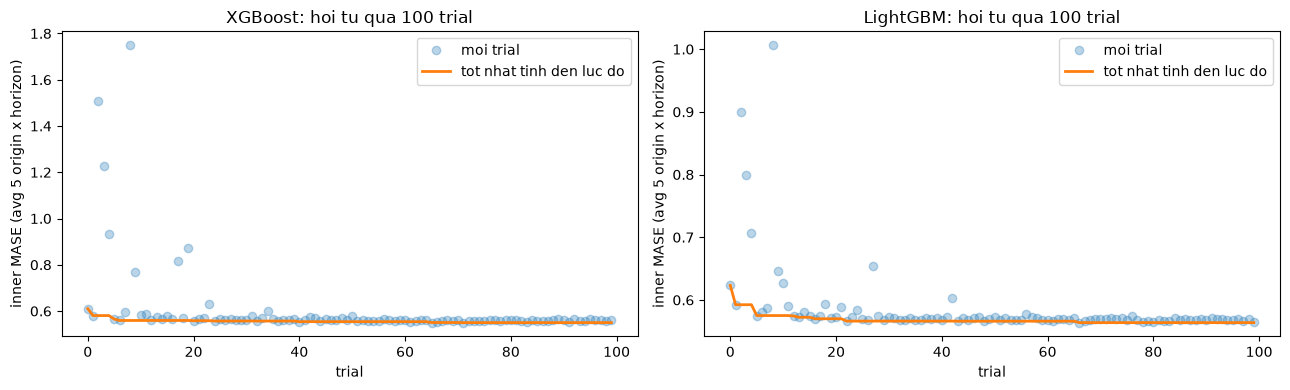

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, study, name in [(axes[0], study_xgb, 'XGBoost'), (axes[1], study_lgb, 'LightGBM')]:
    values = [t.value for t in study.trials]
    best_so_far = np.minimum.accumulate(values)
    ax.plot(values, 'o', alpha=0.3, label='moi trial')
    ax.plot(best_so_far, '-', linewidth=2, label='tot nhat tinh den luc do')
    ax.set_title(f'{name}: hoi tu qua {len(values)} trial')
    ax.set_xlabel('trial'); ax.set_ylabel('inner MASE (avg 5 origin x horizon)')
    ax.legend()
plt.tight_layout()
plt.show()

## Đánh giá cuối: T1 mặc định vs T2 đã tune, trên 8 outer origin (giống hệt exp_002)

In [9]:
rows = []
for name, fit_fn, study in [
    ('M2a_xgboost', fit_predict_m2_xgboost, study_xgb),
    ('M2b_lightgbm', fit_predict_m2_lightgbm, study_lgb),
]:
    t1 = evaluate_params(fit_fn, None, feat_panel, outer_splits, outer_cache)
    t2 = evaluate_params(fit_fn, study.best_params, feat_panel, outer_splits, outer_cache)
    rows.append({'model': name, 'T1_default_MASE': round(t1, 4), 'T2_tuned_MASE': round(t2, 4),
                 'cai_thien_%': round(100*(t1-t2)/t1, 1)})

import pandas as pd

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

       model  T1_default_MASE  T2_tuned_MASE  cai_thien_%
 M2a_xgboost           0.9304         0.9470         -1.8
M2b_lightgbm           0.9374         0.9408         -0.4


## Lưu kết quả

In [10]:
import json

out = {
    'xgboost': {'n_trials': N_TRIALS, 'best_inner_mase': study_xgb.best_value,
                'best_params': study_xgb.best_params,
                'convergence': [t.value for t in study_xgb.trials]},
    'lightgbm': {'n_trials': N_TRIALS, 'best_inner_mase': study_lgb.best_value,
                 'best_params': study_lgb.best_params,
                 'convergence': [t.value for t in study_lgb.trials]},
    'outer_comparison': rows,
}
out_path = _root / 'experiments' / 'exp_003_tuning_m2' / f'results_trials{N_TRIALS}.json'
out_path.write_text(json.dumps(out, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Da luu vao {out_path}')

Da luu vao d:\Cuộc thi\DengueSense\ai-service\experiments\exp_003_tuning_m2\results_trials100.json


**Xong.** Báo lại cho tôi (Claude) kết quả — tôi sẽ đọc `results_trials100.json`, viết `RESULTS.md` cho exp_003, và cập nhật PROGRESS_LOG.md.